# Car Price Prediction with Machine Learning

## Objective

The objective of this project is to build a machine learning regression model
that predicts the selling price of a used car based on features such as car age,
mileage, fuel type, transmission, and brand.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

## 1. Import Required Libraries

In this section, we import the libraries required for data manipulation,
visualization, preprocessing, model building, and evaluation.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. Load the Dataset

The dataset used in this project is the Vehicle Dataset from CarDekho.
We load the CSV file using Pandas and inspect its basic structure.

In [8]:
df = pd.read_csv("car_data.csv")

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## 3. Understand the Dataset

Before building the model, we inspect the dataset to understand its
dimensions, columns, data types, and statistical information.

In [11]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

Dataset Shape: (301, 9)

Column Names:
Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [13]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


## 4. Check for Missing Values

Missing values can affect the performance of machine learning models.
Therefore, we check whether any columns contain null values.

In [16]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

## 5. Check and Remove Duplicate Records

Duplicate records can introduce bias into the analysis.
We check for duplicate rows and remove them if present.

In [19]:
print("Number of duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Number of duplicate rows: 2
Shape after removing duplicates: (299, 9)


## 6. Clean Categorical Variables

Categorical values should be consistent throughout the dataset.
For example, values such as "Petrol" and "petrol" should be treated as
the same category.

In [30]:
categorical_columns = ["Fuel_Type", "Selling_Price", "Transmission"]

for col in categorical_columns:
    df[col] = df[col].astype(str).str.strip().str.title()

df[categorical_columns].head()

,Fuel_Type,Selling_Price,Transmission
0,Petrol,3.35,Manual
1,Diesel,4.75,Manual
2,Petrol,7.25,Manual
3,Petrol,2.85,Manual
4,Diesel,4.6,Manual


## 7. Feature Engineering

### Car Age

The original dataset contains the year in which the car was manufactured.
We calculate the age of the car using the current year.

### Brand

The brand name is extracted from the `Car_Name` column.

In [33]:
current_year = datetime.now().year

df["Car_Age"] = current_year - df["Year"]

df["Brand"] = df["Car_Name"].str.split().str[0]

df[["Car_Name", "Year", "Car_Age", "Brand"]].head()

,Car_Name,Year,Car_Age,Brand
0,ritz,2014,12,ritz
1,sx4,2013,13,sx4
2,ciaz,2017,9,ciaz
3,wagon r,2011,15,wagon
4,swift,2014,12,swift


## 8. Exploratory Data Analysis

Exploratory Data Analysis (EDA) helps us understand the distribution of
selling prices and the relationship between different features and the
selling price.

### Distribution of Selling Prices

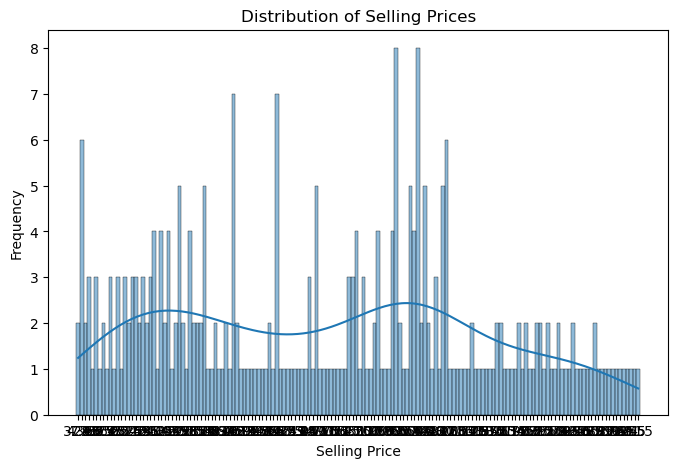

In [37]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Selling_Price"], kde=True)

plt.title("Distribution of Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")

plt.show()

### Selling Price vs Fuel Type

A box plot is used to compare the distribution of selling prices across
different fuel types.

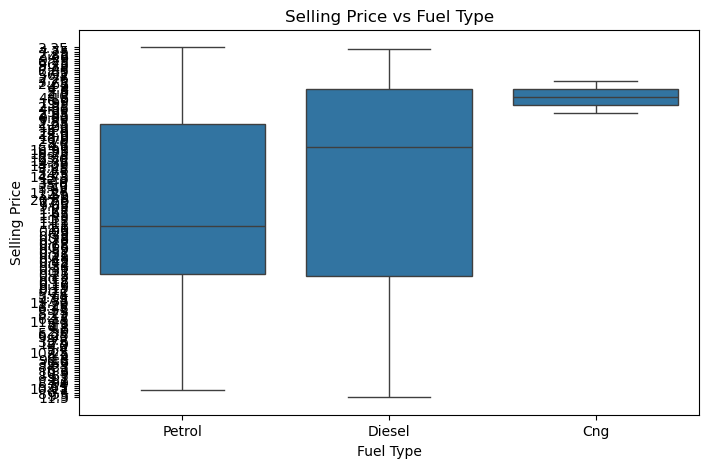

In [40]:
plt.figure(figsize=(8, 5))

sns.boxplot(x="Fuel_Type", y="Selling_Price", data=df)

plt.title("Selling Price vs Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")

plt.show()

### Selling Price vs Car Age

A scatter plot is used to examine the relationship between car age and
selling price.

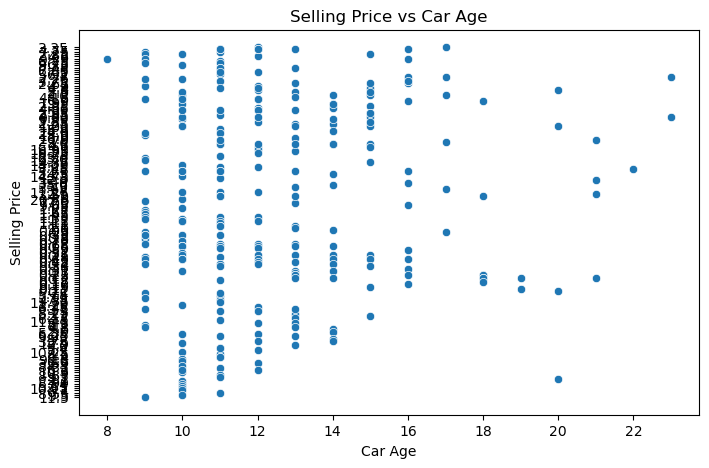

In [43]:
plt.figure(figsize=(8, 5))

sns.scatterplot(x="Car_Age", y="Selling_Price", data=df)

plt.title("Selling Price vs Car Age")
plt.xlabel("Car Age")
plt.ylabel("Selling Price")

plt.show()

## 9. Feature Correlation Heatmap

Correlation analysis helps identify the relationship between numerical
features in the dataset.

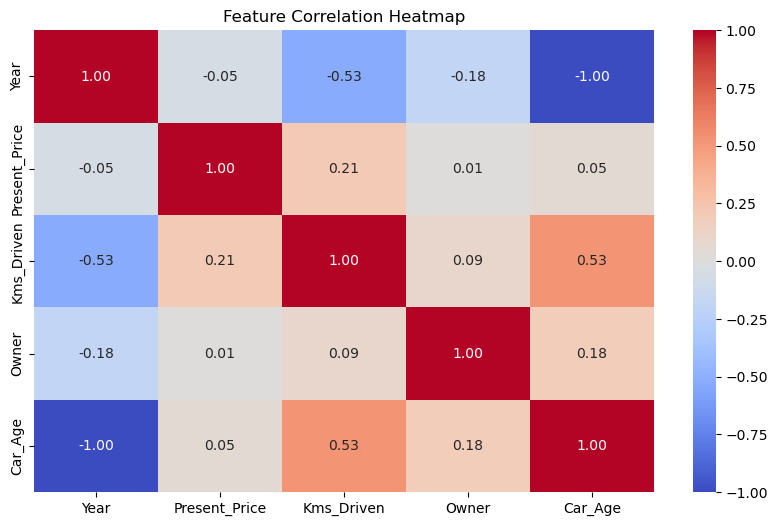

In [46]:
plt.figure(figsize=(10, 6))

correlation = df.select_dtypes(include=np.number).corr()

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Feature Correlation Heatmap")

plt.show()

## 10. Prepare Features and Target

The `Selling_Price` column is selected as the target variable.
The remaining relevant columns are used as input features.

The original `Car_Name` and `Year` columns are removed because we have
already extracted the `Brand` and calculated `Car_Age`.

In [49]:
X = df.drop(
    ["Selling_Price", "Car_Name", "Year"],
    axis=1
)

y = df["Selling_Price"]

print("Features:")
print(X.columns)

print("\nTarget:")
print("Selling_Price")

Features:
Index(['Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type',
       'Transmission', 'Owner', 'Car_Age', 'Brand'],
      dtype='object')

Target:
Selling_Price


## 11. Train-Test Split

The dataset is divided into training and testing sets.

- 80% of the data is used for training.
- 20% of the data is used for testing.

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (239, 8)
Testing data: (60, 8)


## 12. Encode Categorical Variables

Machine learning models require numerical input.
Therefore, categorical features such as brand, fuel type, selling type,
and transmission are converted into numerical representations using
One-Hot Encoding.

In [77]:
categorical_features = [
    "Brand",
    "Fuel_Type",
    "Seller_Type",
    "Transmission"
]

numerical_features = [
    "Present_Price",
    "Kms_Driven",
    "Owner",
    "Car_Age"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)


## 13. Model 1 — Linear Regression

Linear Regression is used as the first regression model.
It attempts to learn a linear relationship between the input features
and the selling price.

In [79]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## 14. Model 2 - Random Forest Regressor

Random Forest Regressor is an ensemble learning algorithm that combines
multiple decision trees to make predictions.

In [82]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


## 15. Model Evaluation

The models are evaluated using three regression metrics:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

Lower MAE and RMSE values indicate better performance, while a higher
R² Score indicates better predictive performance.

In [87]:
def evaluate_model(y_true, predictions):
    mae = mean_absolute_error(y_true, predictions)
    rmse = np.sqrt(mean_squared_error(y_true, predictions))
    r2 = r2_score(y_true, predictions)

    return mae, rmse, r2
linear_mae, linear_rmse, linear_r2 = evaluate_model(
    y_test,
    linear_predictions
)

rf_mae, rf_rmse, rf_r2 = evaluate_model(
    y_test,
    rf_predictions
)

print("Linear Regression")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R² Score:", linear_r2)

print("\nRandom Forest Regressor")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)    

Linear Regression
MAE: 1.3481381543186908
RMSE: 2.388979551350318
R² Score: 0.7785603061203061

Random Forest Regressor
MAE: 1.3824524999999996
RMSE: 3.356000365657263
R² Score: 0.5630068728909015


## 16. Model Comparison

The performance of Linear Regression and Random Forest Regressor is
compared using MAE, RMSE, and R² Score.

In [90]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest Regressor"
    ],
    "MAE": [
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse
    ],
    "R² Score": [
        linear_r2,
        rf_r2
    ]
})

results

,Model,MAE,RMSE,R² Score
0,Linear Regression,1.348138,2.38898,0.778560
1,Random Forest Regressor,1.382452,3.35600,0.563007


## 17. Best Performing Model

The model with the highest R² Score and comparatively lower MAE and RMSE
is considered the best-performing model.

In [93]:
best_model = results.loc[
    results["R² Score"].idxmax()
]

print("Best Performing Model:", best_model["Model"])
print("MAE:", best_model["MAE"])
print("RMSE:", best_model["RMSE"])
print("R² Score:", best_model["R² Score"])

Best Performing Model: Linear Regression
MAE: 1.3481381543186908
RMSE: 2.388979551350318
R² Score: 0.7785603061203061


## 18. Feature Importance

Feature importance is calculated for the Random Forest Regressor to
identify the features that contribute most to predicting the selling price.

In [96]:
rf_preprocessor = rf_model.named_steps["preprocessor"]
rf_regressor = rf_model.named_steps["model"]

feature_names = rf_preprocessor.get_feature_names_out()

importances = rf_regressor.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
46,remainder__Present_Price,0.887533
49,remainder__Car_Age,0.066969
31,cat__Brand_land,0.015712
47,remainder__Kms_Driven,0.011080
44,cat__Transmission_Automatic,0.003499
45,cat__Transmission_Manual,0.002999
17,cat__Brand_corolla,0.002957
29,cat__Brand_innova,0.001703
43,cat__Seller_Type_Individual,0.001263
42,cat__Seller_Type_Dealer,0.001156


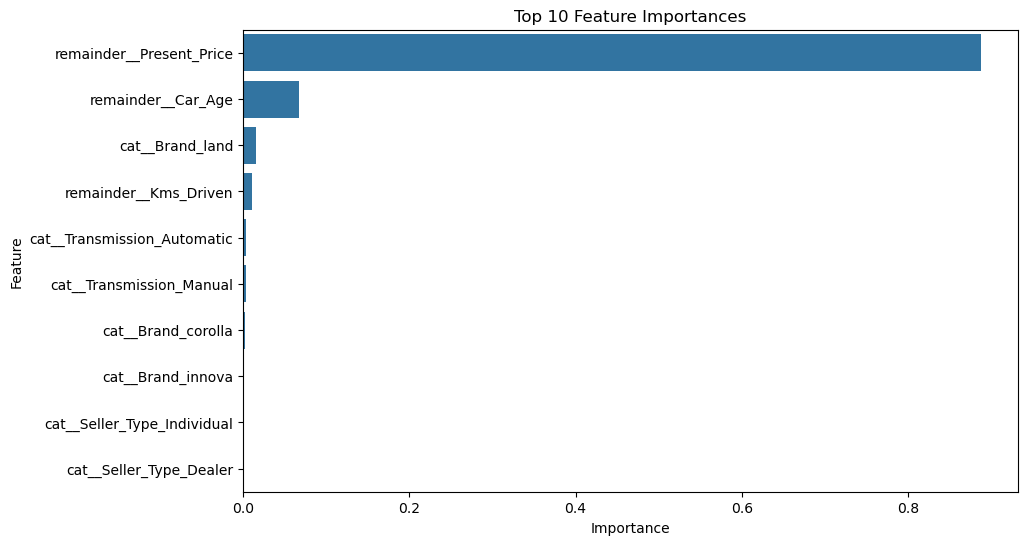

In [98]:
### Top 10 Important Features
plt.figure(figsize=(10, 6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(10)
)

plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## 19. Conclusion

In this project, a machine learning regression system was developed to
predict the selling price of used cars.

The dataset was cleaned by removing duplicate records and maintaining
consistent categorical values. Feature engineering was performed by
calculating car age from the manufacturing year and extracting the brand
from the car name.

Exploratory Data Analysis was performed using a selling price distribution
plot, fuel type box plot, car age scatter plot, and correlation heatmap.

Two regression models, Linear Regression and Random Forest Regressor,
were trained and evaluated using MAE, RMSE, and R² Score.

The model with the best evaluation performance was selected as the
best-performing model. Feature importance analysis was also performed
using the Random Forest Regressor to identify the most influential
features affecting car selling prices.

This project demonstrates the complete machine learning workflow,
including data cleaning, feature engineering, exploratory data analysis,
categorical encoding, model training, evaluation, and interpretation.